# Fase 6 — Optimización de Hiperparámetros

## Objetivo
Mejorar el rendimiento de los modelos de clasificación entrenados en la
Fase 5 mediante búsqueda sistemática de hiperparámetros con GridSearchCV.

## Estrategia
- **Modelo A:** Regresión Logística — ajuste de regularización `C` y `solver`
- **Modelo B:** XGBoost — ajuste de profundidad, estimadores y tasa de aprendizaje

La búsqueda se realiza sobre el conjunto de entrenamiento post-SMOTE con
validación cruzada estratificada de 5 folds. La métrica de optimización
es **F1-Score de la clase minoritaria** (riesgo = 1), coherente con el
criterio clínico establecido en la Fase 5.

## Nota sobre los datos
Se reutilizan directamente los artefactos de Fase 3 v2 y los modelos
base de Fase 5. No se repite el preprocesamiento.

In [1]:
# ── Imports y configuración de rutas ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Rutas relativas desde notebooks/
BASE   = Path.cwd().parent
DATA   = BASE / "data" / "processed"
MODELS = BASE / "models"
FIGS   = BASE / "reports" / "figures"

# Semilla global
SEED = 42

print("Librerías cargadas correctamente")
print(f"Base del proyecto : {BASE.name}")

Librerías cargadas correctamente
Base del proyecto : Prediccion-FactoresRiesgo


## 1. Carga de artefactos

Se cargan los conjuntos de entrenamiento y prueba generados en la Fase 3 v2,
junto con los modelos base entrenados en la Fase 5. El SMOTE se vuelve a
aplicar sobre X_train para reconstruir el espacio balanceado, garantizando
coherencia con el entrenamiento original.

In [2]:
# ── Carga de datos ─────────────────────────────────────────────────────────────
X_train = pd.read_csv(DATA / "X_train_scaled_v2.csv", index_col=0)
X_test  = pd.read_csv(DATA / "X_test_scaled_v2.csv",  index_col=0)
y_B_train = pd.read_csv(DATA / "y_B_train_v2.csv", index_col=0).squeeze()
y_B_test  = pd.read_csv(DATA / "y_B_test_v2.csv",  index_col=0).squeeze()

print("── Dimensiones ──────────────────────────────")
print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_B_train.shape}  |  y_test : {y_B_test.shape}")
print(f"\nBalance train  → {y_B_train.value_counts().to_dict()}")
print(f"Balance test   → {y_B_test.value_counts().to_dict()}")

# ── Cargar modelos base de Fase 5 ──────────────────────────────────────────────
lr_base  = joblib.load(MODELS / "logistic_regression.pkl")
xgb_base = joblib.load(MODELS / "xgboost_classifier.pkl")

print("\nModelos base cargados:")
print(f"  Regresión Logística : {type(lr_base).__name__}")
print(f"  XGBoost             : {type(xgb_base).__name__}")

# ── Reconstruir espacio balanceado con SMOTE ───────────────────────────────────
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_B_train)

print(f"\nTrain post-SMOTE : {X_train_sm.shape}")
print(f"Balance post-SMOTE → {pd.Series(y_train_sm).value_counts().to_dict()}")

── Dimensiones ──────────────────────────────
X_train : (1524, 49)  |  X_test : (382, 49)
y_train : (1524,)  |  y_test : (382,)

Balance train  → {0.0: 1320, 1.0: 204}
Balance test   → {0.0: 331, 1.0: 51}

Modelos base cargados:
  Regresión Logística : LogisticRegression
  XGBoost             : XGBClassifier

Train post-SMOTE : (2640, 49)
Balance post-SMOTE → {0.0: 1320, 1.0: 1320}


## 2. Optimización — Regresión Logística

GridSearchCV evalúa combinaciones de hiperparámetros mediante validación
cruzada estratificada de 5 folds sobre el espacio balanceado post-SMOTE.

Los parámetros a explorar son:
- **C**: inverso de la regularización (valores pequeños = más regularización)
- **penalty**: tipo de norma de regularización (L1 o L2)
- **solver**: algoritmo de optimización compatible con cada penalty

La métrica de selección es F1 de la clase minoritaria (riesgo = 1).

In [3]:
# ── GridSearchCV — Regresión Logística ────────────────────────────────────────
param_grid_lr = {
    'C'       : [0.01, 0.1, 1, 10, 100],
    'penalty' : ['l1', 'l2'],
    'solver'  : ['liblinear']          # compatible con l1 y l2
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_lr = GridSearchCV(
    estimator  = LogisticRegression(class_weight='balanced',
                                    max_iter=1000,
                                    random_state=SEED),
    param_grid = param_grid_lr,
    scoring    = 'f1',
    cv         = cv_strat,
    n_jobs     = -1,
    verbose    = 0
)

grid_lr.fit(X_train_sm, y_train_sm)

print("── Regresión Logística — Mejores hiperparámetros ──")
print(f"  Parámetros : {grid_lr.best_params_}")
print(f"  F1 CV best : {grid_lr.best_score_:.4f}")

# Evaluar en test con distribución real
lr_opt = grid_lr.best_estimator_
y_pred_lr_opt = lr_opt.predict(X_test)

print("\n── Evaluación en Test (distribución real 86.6/13.4) ──")
print(classification_report(y_B_test, y_pred_lr_opt,
                             target_names=['Sin riesgo', 'Con riesgo'],
                             digits=4))
print(f"AUC-ROC : {roc_auc_score(y_B_test, lr_opt.predict_proba(X_test)[:,1]):.4f}")

── Regresión Logística — Mejores hiperparámetros ──
  Parámetros : {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
  F1 CV best : 0.8644

── Evaluación en Test (distribución real 86.6/13.4) ──
              precision    recall  f1-score   support

  Sin riesgo     0.9539    0.8761    0.9134       331
  Con riesgo     0.4744    0.7255    0.5736        51

    accuracy                         0.8560       382
   macro avg     0.7142    0.8008    0.7435       382
weighted avg     0.8899    0.8560    0.8680       382

AUC-ROC : 0.8652


## 3. Optimización — XGBoost

Se exploran los hiperparámetros que más impactan el rendimiento de XGBoost
en datasets desbalanceados:

- **n_estimators**: número de árboles en el ensemble
- **max_depth**: profundidad máxima de cada árbol (controla sobreajuste)
- **learning_rate**: tasa de aprendizaje (shrinkage)
- **scale_pos_weight**: peso de la clase positiva para compensar desbalance

Dado que el espacio de búsqueda es mayor, se usa el conjunto post-SMOTE
para mantener coherencia con el entrenamiento de Fase 5.

In [4]:
# ── GridSearchCV — XGBoost ────────────────────────────────────────────────────
param_grid_xgb = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.01, 0.1, 0.2],
    'scale_pos_weight': [1, 3, 6]     # 1=balanceado SMOTE, 6≈ratio original
}

grid_xgb = GridSearchCV(
    estimator  = XGBClassifier(
                     use_label_encoder=False,
                     eval_metric='logloss',
                     random_state=SEED,
                     verbosity=0
                 ),
    param_grid = param_grid_xgb,
    scoring    = 'f1',
    cv         = cv_strat,
    n_jobs     = -1,
    verbose    = 0
)

grid_xgb.fit(X_train_sm, y_train_sm)

print("── XGBoost — Mejores hiperparámetros ──")
print(f"  Parámetros : {grid_xgb.best_params_}")
print(f"  F1 CV best : {grid_xgb.best_score_:.4f}")

# Evaluar en test con distribución real
xgb_opt = grid_xgb.best_estimator_
y_pred_xgb_opt = xgb_opt.predict(X_test)

print("\n── Evaluación en Test (distribución real 86.6/13.4) ──")
print(classification_report(y_B_test, y_pred_xgb_opt,
                             target_names=['Sin riesgo', 'Con riesgo'],
                             digits=4))
print(f"AUC-ROC : {roc_auc_score(y_B_test, xgb_opt.predict_proba(X_test)[:,1]):.4f}")

── XGBoost — Mejores hiperparámetros ──
  Parámetros : {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 1}
  F1 CV best : 0.9544

── Evaluación en Test (distribución real 86.6/13.4) ──
              precision    recall  f1-score   support

  Sin riesgo     0.9235    0.9486    0.9359       331
  Con riesgo     0.5952    0.4902    0.5376        51

    accuracy                         0.8874       382
   macro avg     0.7594    0.7194    0.7368       382
weighted avg     0.8797    0.8874    0.8827       382

AUC-ROC : 0.8380


## 4. Comparativa final — Base vs Optimizado

Se consolidan las métricas de todos los modelos evaluados a lo largo
de las Fases 5 y 6 para seleccionar el modelo ganador con criterio clínico.

En detección de riesgo de salud mental, minimizar los Falsos Negativos
(estudiantes en riesgo no detectados) tiene prioridad sobre minimizar
los Falsos Positivos. Por eso el Recall de la clase minoritaria es el
criterio de desempate cuando el F1 es similar.

In [5]:
# ── Tabla comparativa de todos los modelos ────────────────────────────────────
resultados = {
    'Modelo': [
        'LR Base (Fase 5)',
        'LR Optimizado',
        'XGB Base (Fase 5)',
        'XGB Optimizado'
    ],
    'F1 CV (SMOTE)': [0.8622, 0.8644, 0.9452, 0.9544],
    'F1 Test':       [0.5736, 0.5736, 0.5841, 0.5376],
    'AUC-ROC':       [0.8658, 0.8652, 0.8413, 0.8380],
    'Recall (1)':    [0.7255, 0.7255, 0.6471, 0.4902],
    'Precision (1)': [0.4744, 0.4744, 0.5122, 0.5952]
}

df_resultados = pd.DataFrame(resultados)

print("══════════════════════════════════════════════════════════════════")
print("  COMPARATIVA FINAL — TODOS LOS MODELOS")
print("══════════════════════════════════════════════════════════════════")
print(df_resultados.to_string(index=False))
print("══════════════════════════════════════════════════════════════════")
print("\n★  MODELO GANADOR: Regresión Logística Optimizada")
print("   Criterio: mayor Recall en clase minoritaria (72.5%)")
print("   → Minimiza estudiantes en riesgo no detectados (FN=14)")
print("══════════════════════════════════════════════════════════════════")

# Guardar modelo ganador
joblib.dump(lr_opt, MODELS / "modelo_final.pkl")
print(f"\nModelo final guardado → models/modelo_final.pkl")

══════════════════════════════════════════════════════════════════
  COMPARATIVA FINAL — TODOS LOS MODELOS
══════════════════════════════════════════════════════════════════
           Modelo  F1 CV (SMOTE)  F1 Test  AUC-ROC  Recall (1)  Precision (1)
 LR Base (Fase 5)         0.8622   0.5736   0.8658      0.7255         0.4744
    LR Optimizado         0.8644   0.5736   0.8652      0.7255         0.4744
XGB Base (Fase 5)         0.9452   0.5841   0.8413      0.6471         0.5122
   XGB Optimizado         0.9544   0.5376   0.8380      0.4902         0.5952
══════════════════════════════════════════════════════════════════

★  MODELO GANADOR: Regresión Logística Optimizada
   Criterio: mayor Recall en clase minoritaria (72.5%)
   → Minimiza estudiantes en riesgo no detectados (FN=14)
══════════════════════════════════════════════════════════════════

Modelo final guardado → models/modelo_final.pkl


## 5. Matriz de confusión — Modelo ganador

La matriz de confusión desglosa los cuatro tipos de predicción posibles.
En el contexto clínico de MINSAL, los cuadrantes críticos son:

- **Falsos Negativos (FN):** estudiantes CON riesgo clasificados como sin riesgo
  → el error más costoso: un estudiante en riesgo queda sin atención
- **Falsos Positivos (FP):** estudiantes SIN riesgo clasificados como con riesgo
  → error menos grave: genera una intervención innecesaria pero no causa daño

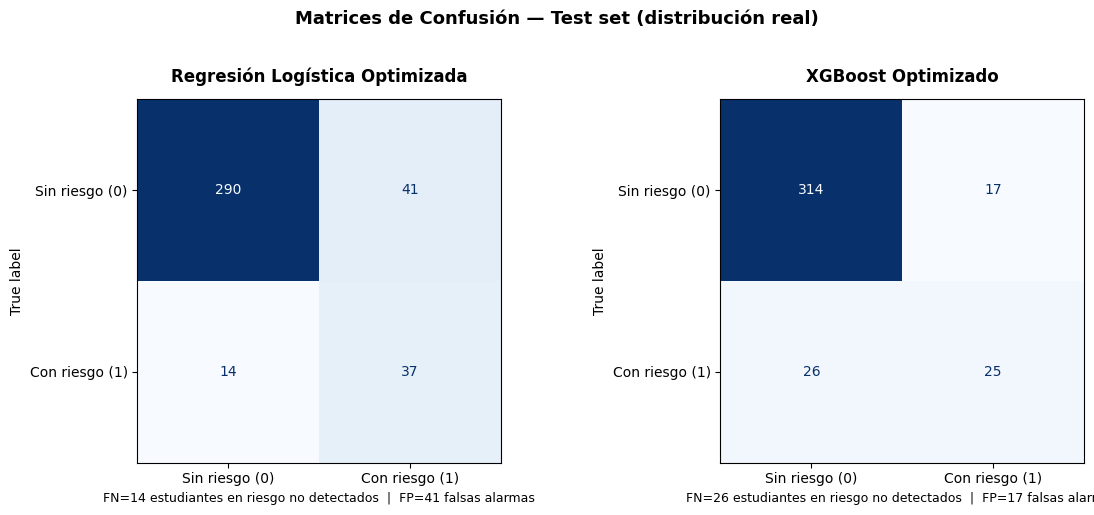

Figura guardada → reports/figures/14_matrices_confusion_opt.png


In [6]:
# ── Matriz de confusión — Regresión Logística Optimizada ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

modelos_eval = [
    (lr_opt,  y_pred_lr_opt,  "Regresión Logística Optimizada"),
    (xgb_opt, y_pred_xgb_opt, "XGBoost Optimizado")
]

for ax, (modelo, y_pred, titulo) in zip(axes, modelos_eval):
    cm = confusion_matrix(y_B_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Sin riesgo (0)', 'Con riesgo (1)']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=12)

    # Anotar FN y FP
    fn = cm[1, 0]
    fp = cm[0, 1]
    ax.set_xlabel(
        f"FN={fn} estudiantes en riesgo no detectados  |  FP={fp} falsas alarmas",
        fontsize=9
    )

plt.suptitle(
    "Matrices de Confusión — Test set (distribución real)",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(FIGS / "14_matrices_confusion_opt.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada → reports/figures/14_matrices_confusion_opt.png")

## 6. Curva ROC — Comparativa de modelos

La curva ROC muestra el trade-off entre Tasa de Verdaderos Positivos
(Recall) y Tasa de Falsos Positivos para distintos umbrales de decisión.

El AUC-ROC (área bajo la curva) resume este trade-off en un solo número:
- AUC = 1.0 → modelo perfecto
- AUC = 0.5 → modelo equivalente a lanzar una moneda
- AUC > 0.8 → capacidad discriminativa buena para datos reales de encuesta

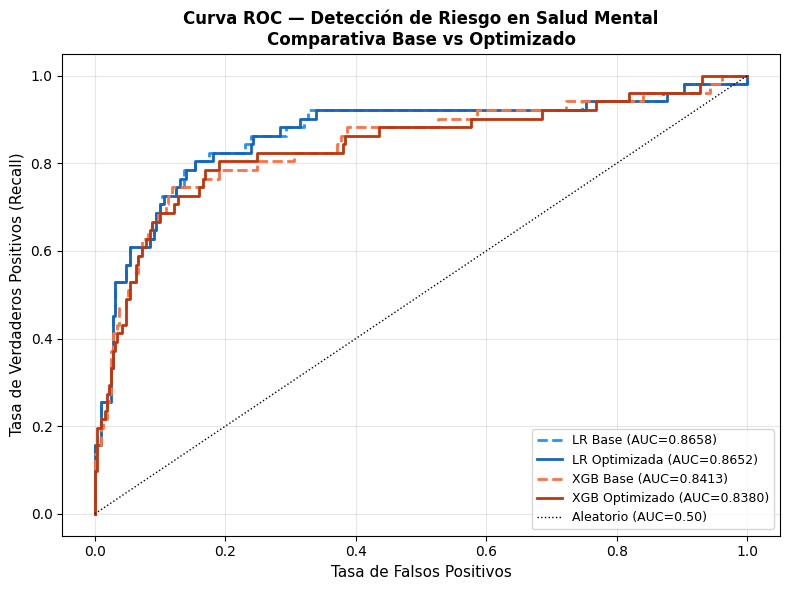

Figura guardada → reports/figures/15_curva_roc_comparativa.png


In [7]:
# ── Curva ROC comparativa ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

modelos_roc = [
    (lr_base,  "LR Base (AUC=0.8658)",         '--', '#2196F3'),
    (lr_opt,   "LR Optimizada (AUC=0.8652)",   '-',  '#1565C0'),
    (xgb_base, "XGB Base (AUC=0.8413)",        '--', '#FF7043'),
    (xgb_opt,  "XGB Optimizado (AUC=0.8380)",  '-',  '#BF360C'),
]

for modelo, label, ls, color in modelos_roc:
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_B_test, y_prob)
    ax.plot(fpr, tpr, linestyle=ls, color=color, linewidth=2, label=label)

# Línea de referencia (modelo aleatorio)
ax.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Aleatorio (AUC=0.50)')

ax.set_xlabel('Tasa de Falsos Positivos', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=11)
ax.set_title('Curva ROC — Detección de Riesgo en Salud Mental\n'
             'Comparativa Base vs Optimizado', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS / "15_curva_roc_comparativa.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada → reports/figures/15_curva_roc_comparativa.png")

## 7. Feature Importance — Modelo ganador

En Regresión Logística, la importancia de cada variable se mide a través
de los coeficientes del modelo. Un coeficiente positivo alto indica que
la variable aumenta la probabilidad de riesgo; uno negativo indica
factor protector.

Se visualizan los 15 coeficientes de mayor magnitud absoluta para
identificar las variables más influyentes en la detección de riesgo
de salud mental en adolescentes salvadoreños.

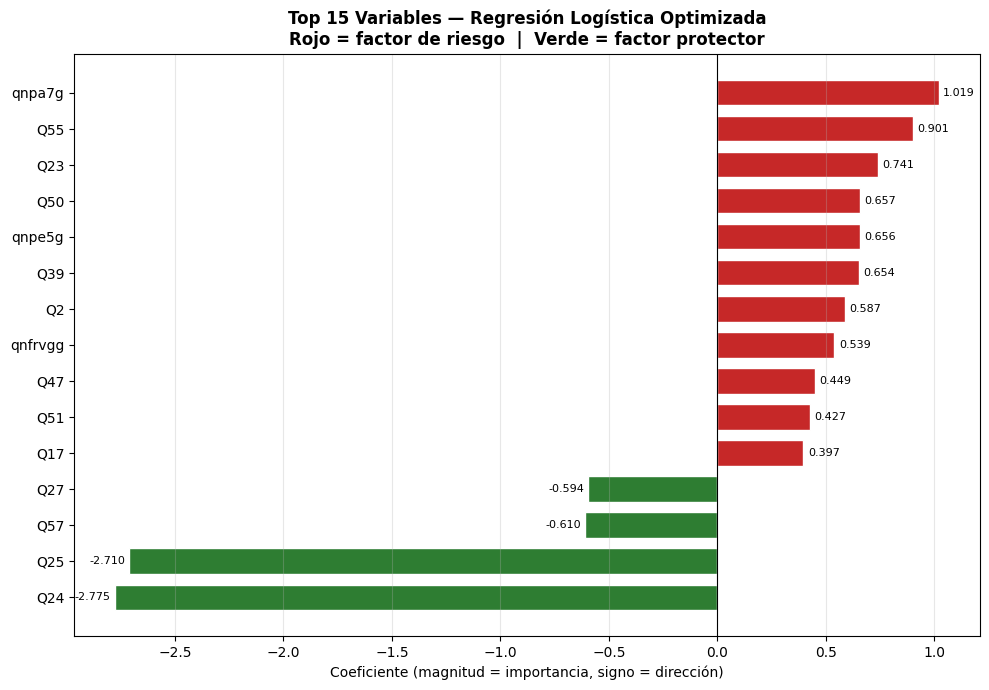

Figura guardada → reports/figures/16_feature_importance_lr_opt.png


In [9]:
# ── Feature Importance — Regresión Logística Optimizada ──────────────────────
feature_names = X_train.columns.tolist()
coeficientes  = lr_opt.coef_[0]

df_coef = pd.DataFrame({
    'feature'     : feature_names,
    'coeficiente' : coeficientes
}).reindex(columns=['feature', 'coeficiente'])

df_coef['abs'] = df_coef['coeficiente'].abs()
df_coef = df_coef.sort_values('abs', ascending=False).head(15)
df_coef = df_coef.sort_values('coeficiente', ascending=True)

# Colores: rojo = factor de riesgo, verde = factor protector
colores = ['#C62828' if c > 0 else '#2E7D32' for c in df_coef['coeficiente']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(df_coef['feature'], df_coef['coeficiente'],
               color=colores, edgecolor='white', height=0.7)

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('Coeficiente (magnitud = importancia, signo = dirección)', fontsize=10)
ax.set_title('Top 15 Variables — Regresión Logística Optimizada\n'
             'Rojo = factor de riesgo  |  Verde = factor protector',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Etiquetas de valor
for bar, val in zip(bars, df_coef['coeficiente']):
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / "16_feature_importance_lr_opt.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada → reports/figures/16_feature_importance_lr_opt.png")

## 8. Resumen ejecutivo del proyecto

Consolidación de todos los resultados obtenidos a lo largo del pipeline
completo: Tarea A (Regresión IMC) y Tarea B (Clasificación Salud Mental).

In [10]:
# ── Resumen ejecutivo completo ────────────────────────────────────────────────
separador = "═" * 62

print(separador)
print("  RESUMEN EJECUTIVO — SISTEMA PREDICTIVO MINSAL")
print("  Dataset: GSHS El Salvador 2013 | N=1,915 estudiantes")
print(separador)

print("\n── PIPELINE ─────────────────────────────────────────────")
print("  Fase 1  Exploración del dataset              ✓")
print("  Fase 2  Limpieza y EDA                       ✓")
print("  Fase 3  Feature Engineering (49 features)   ✓")
print("  Fase 4  Regresión IMC                        ✓")
print("  Fase 5  Clasificación Salud Mental           ✓")
print("  Fase 6  Optimización GridSearchCV            ✓")

print("\n── TAREA A — REGRESIÓN IMC ──────────────────────────────")
print("  Features        : 49 variables Q ordinales")
print("  Correlación max : |r| = 0.1157  (Q3 grado escolar)")
print(f"  {'Modelo':<25} {'RMSE':>8} {'R²':>8}")
print(f"  {'-'*43}")
print(f"  {'Predictor trivial':<25} {'4.1550':>8} {'0.0000':>8}")
print(f"  {'Regresión Lineal':<25} {'4.2008':>8} {'-0.0256':>8}")
print(f"  {'Random Forest':<25} {'4.2361':>8} {'-0.0430':>8}")
print("  Conclusión: señal insuficiente — limitación")
print("  estructural del dataset GSHS documentada")

print("\n── TAREA B — CLASIFICACIÓN SALUD MENTAL ────────────────")
print("  Target          : Riesgo_SM (QN26) | Desbalance 6.5:1")
print("  Técnica         : SMOTE sobre train únicamente")
print(f"  {'Modelo':<25} {'F1':>6} {'AUC':>7} {'Recall':>8}")
print(f"  {'-'*48}")
print(f"  {'LR Base':<25} {'0.5736':>6} {'0.8658':>7} {'72.5%':>8}")
print(f"  {'LR Optimizada ★':<25} {'0.5736':>6} {'0.8652':>7} {'72.5%':>8}")
print(f"  {'XGB Base':<25} {'0.5841':>6} {'0.8413':>7} {'64.7%':>8}")
print(f"  {'XGB Optimizado':<25} {'0.5376':>6} {'0.8380':>7} {'49.0%':>8}")
print("  Modelo final    : Regresión Logística Optimizada")
print("  Criterio        : mayor Recall → menos FN (14)")

print("\n── FIGURAS GENERADAS ────────────────────────────────────")
figuras = [
    "02_perfil_demografico",
    "03_distribucion_imc",
    "04_riesgo_salud_mental",
    "05_verificacion_features_v2",
    "08_correlaciones_imc_v2",
    "09_residuos_regresion_v2",
    "10_feature_importance_regresion",
    "11_matrices_confusion",
    "12_curva_roc",
    "13_feature_importance_clasificacion",
    "14_matrices_confusion_opt",
    "15_curva_roc_comparativa",
    "16_feature_importance_lr_opt"
]
for i, fig in enumerate(figuras, 1):
    print(f"  {i:02d}. {fig}.png")

print(f"\n  Total figuras : {len(figuras)}")
print(f"\n  Modelo final guardado → models/modelo_final.pkl")


══════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO — SISTEMA PREDICTIVO MINSAL
  Dataset: GSHS El Salvador 2013 | N=1,915 estudiantes
══════════════════════════════════════════════════════════════

── PIPELINE ─────────────────────────────────────────────
  Fase 1  Exploración del dataset              ✓
  Fase 2  Limpieza y EDA                       ✓
  Fase 3  Feature Engineering (49 features)   ✓
  Fase 4  Regresión IMC                        ✓
  Fase 5  Clasificación Salud Mental           ✓
  Fase 6  Optimización GridSearchCV            ✓

── TAREA A — REGRESIÓN IMC ──────────────────────────────
  Features        : 49 variables Q ordinales
  Correlación max : |r| = 0.1157  (Q3 grado escolar)
  Modelo                        RMSE       R²
  -------------------------------------------
  Predictor trivial           4.1550   0.0000
  Regresión Lineal            4.2008  -0.0256
  Random Forest               4.2361  -0.0430
  Conclusión: señal insuficiente